# Identifying Key Predictors of Diabetes Through Data Analytics

The capstone aims to answer the research question:
Can predictive analytics be used to predict diabetes risk and inform early screening and decisions for preventive care? 

Hypothesis:
People with elevated blood pressure and higher body mass index (BMI), as well as advanced age, have an increased likelihood of developing diabetes compared to those with a normal health range. 


This capstone project utilizes the 2015 Centers for Disease Control and Prevention (CDC) dataset, which can be accessed through the Kaggle website. The dataset includes over 250,000 anonymous survey responses from adults across the United States. The survey dataset contains health indicators such as BMI, blood pressure, cholesterol, physical activity and along with other indicators as well.

By applying data analytics techniques on the health dataset, this capstone project seeks to identify determine which health indicators most strongly predict diabetes risk.

For this capstone, the following Python Libraries are required: 
* Pandas: For loading, cleaning, and manipulating the data within the CSV files. 
* Numpy: Optimized for handling large datasets, it quickly performs optimized mathematical operations on large arrays. 
* Zipfile: Opens the zipfile, looks inside it, and reads and extracts files from it.
* Matplotlib: Create visual charts and identify data patterns.
* Seaborn: For the generation of clear, easy-to-understand visualizations during the exploratory analysis.
* Scikit-learn: For building, training, and evaluating machine learning models. It provides user-friendly tools for splitting data into training and testing sets, applying algorithms such as logistic regression and random forest. It also includes performance metrics such as accuracy, recall, and ROC-AUC. In Jupyter notebook the it is called "sklearn" instead of scikit-learn.

In [72]:
# Imported these libraries to load, clean, transfrom the data.
import pandas as pd 
import numpy as np

# Since the data is in a zip file, this library is required to extract the contents inside the zip to analyze them.
import zipfile

# Imported these libraries for exploratory data analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# Import this library to build, train and evaluate the for machine learning model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score,roc_curve
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## 1. Import and Load Dataset

In [73]:
# Step 1: Read the zipped CSV files.
zip_path = "Diabetes.zip"

# Step 2: Open the Zip file, while it is open, it will be called zip_ref. 
#Print the list of the files inside the ZIP.
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print(zip_ref.namelist())

['diabetes_012_health_indicators_BRFSS2015.csv', 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv']


The zip file has three CSV files:
* **'diabetes_binary_health_indicators_BRFSS2015.csv'**
This is the full dataset; it is known as unbalanced because the population is not evenly distributed. It can have a disproportionate number of people in either diabetic outcomes. This dataset will be used.
* **'diabetes_binary_5050split_health_indicators_BRFSS2015.csv'**
This dataset is known as a balanced version, meaning there is a 50/50 split between diabetic and non-diabetic individuals. This is artificially balanced; it does not accurately reflect the dataset, as it is evenly divided between individuals with diabetes and those without diabetes. For this reason, this dataset will not be selected going forward.
* **'diabetes_012_health_indicators_BRFSS2015.csv'**
This dataset is known as a multi-class version. Instead of a binary response, diabetes (2), no diabetes (0), it was a third label (1), prediabetes. For this capstone, this is outside the scope of the project and therefore will not be used going forward.

In [74]:
# This will confrom the seperate csv's are stuctured the same way.
with zipfile.ZipFile(zip_path, "r") as zip_ref:
        df= pd.read_csv(zip_ref.open("diabetes_binary_health_indicators_BRFSS2015.csv"))
        
        print("Shape:", df.shape)
        print("Columns:", list(df.columns[:]), "...\n")

Shape: (253680, 22)
Columns: ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income'] ...



###  **diabetes_binary_health_indicators_BRFSS2015.csv:**
- This dataset has the dimensions of 253,680 rows × 22 columns. It is the real world representation of people who have diabetes compared to the rest of the real world. 

In [75]:
# Displayed the first few rows of the dataset.
print("First 10 rows if the full unbalanced dataset:")
display(df.head(10))

First 10 rows if the full unbalanced dataset:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0



## 2. Exploratory data analysis

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [77]:
df['Diabetes_binary'].value_counts()

0.0    218334
1.0     35346
Name: Diabetes_binary, dtype: int64

### All columns are in the proper data type within the dataset. There is no missing data within the datasets.

In [78]:
# A basic statistical summary is performed to gain an initial understanding of a dataset before modeling.
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


 The statistical summary comprises 253,680 observations across 22 variables, with a mean BMI of about 28, indicating an overweight average among participants. Around 43% reported high blood pressure, and 42% reported high cholesterol, indicating common cardiovascular risk factors. The average age category is 8, which corresponds to middle-aged adults. Most respondents reported having access to healthcare (95%) and regular cholesterol checks (96%), but only 14% reported being diabetic. Overall, the data reflect a diverse U.S. population with a broad range of health characteristics, making it suitable for predicting diabetes risk.

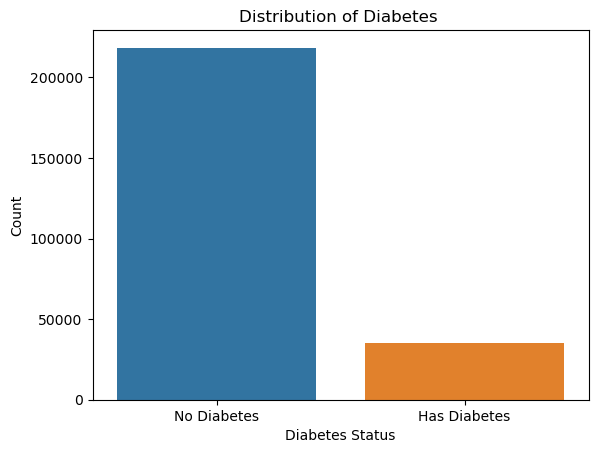

In [79]:
# Diabetes status distribution of unbalanced dataset.

sns.countplot(x='Diabetes_binary',data=df_unbalanced)
plt.title("Distribution of Diabetes ")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")

#Replacing x-axis to 0.0 to equal "No Diabetes", and 1.0 to equal "Has diabetes".
plt.xticks(ticks=[0,1], labels=["No Diabetes", "Has Diabetes"])

plt.show()

 This column chart shows the distribution of diabetes status in the unbalanced dataset. The chart reveals a clear class imbalance, with more people reporting no diabetes compared to those who have diabetes.

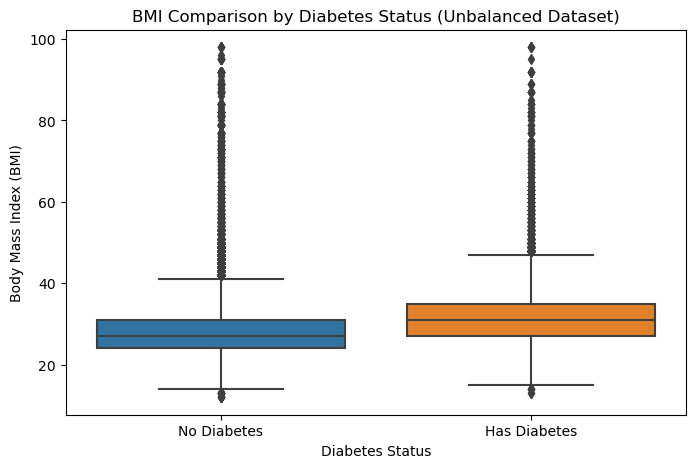

In [80]:
#BMI distribtion
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Diabetes_binary", 
    y="BMI", 
    data=df_unbalanced, 
    )

plt.title("BMI Comparison by Diabetes Status (Unbalanced Dataset)")

plt.xlabel("Diabetes Status")
plt.ylabel("Body Mass Index (BMI)")


#Replacing x-axis to 0.0 to equal "No Diabetes", and 1.0 to equal "Has diabetes".
plt.xticks(ticks=[0,1], labels=["No Diabetes", "Has Diabetes"])


plt.show()

 For the unbalanced data, this box plot compares Body Mass Index (BMI) between individuals with and without diabetes. It shows that people with diabetes generally have a higher median BMI and a wider range of values compared to those without diabetes.

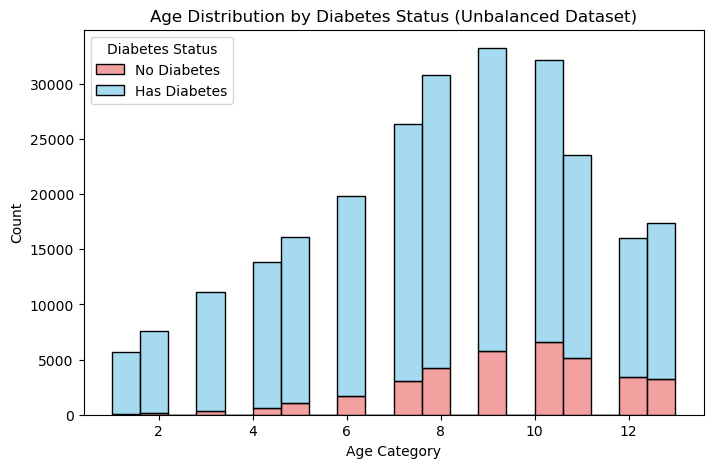

In [81]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Age",
    hue="Diabetes_binary",
    multiple="stack",   
    bins=20,
    palette=["skyblue", "lightcoral"]
)

plt.title("Age Distribution by Diabetes Status (Unbalanced Dataset)")
plt.xlabel("Age Category")
plt.ylabel("Count")
plt.legend(title="Diabetes Status", labels=["No Diabetes", "Has Diabetes"])

plt.show()
 


 For the unbalanced dataset, this stacked column chart shows the age distribution by diabetes status. It shows that the number of diabetes cases increases with age, particularly in the older age categories. Most individuals without diabetes are contracted in the middle age, while diabetes becomes more prevalent in higher age brackets. 

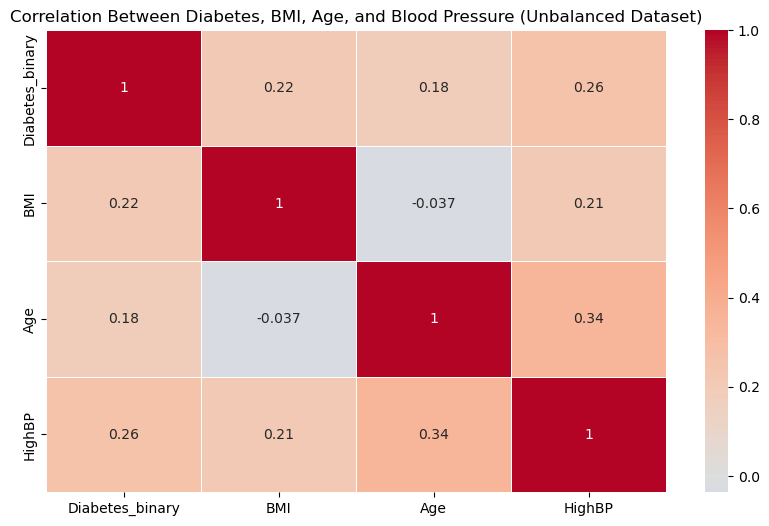

In [82]:
# Select only relevant columns
corr_vars = ['Diabetes_binary', 'BMI', 'Age', 'HighBP']

# Compute correlation
corr = df[corr_vars].corr()

# Plot the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    corr, 
    annot=True,       # shows the numeric correlation values
    cmap="coolwarm", 
    center=0, 
    linewidths=0.5
)

plt.title("Correlation Between Diabetes, BMI, Age, and Blood Pressure (Unbalanced Dataset)")
plt.show()

For the unbalanced dataset, this correlation heatmap shows the relationship between diabetes, BMI, age, and high blood pressure. All three health indicators —BMI (0.22), age (0.18), and high blood pressure (0.26) —are positively correlated with diabetes, meaning that higher values in these variables are associated with a greater likelihood of having diabetes.

## 3. Prepare the data

 The first step in preparing the health data for modeling is to clean the data. Dropping duplicates is a crucial step in the data cleaning process. Duplicates can introduce bias in the learning model by giving extra weight to repeated data points. This can cause the model to "overlearn" specific patterns and reduce its ability to generalize to new data, making relationships between variables appear stronger than they really are. In this context, generalization refers to how well a model can apply what it has learned from the training data to make accurate predictions on new, unseen data. It shows the model's ability to recognize real patterns rather than just memorize examples.

In [83]:
# Verified that the diabetes column from the unbalanced dataset is binary.
print("Unique values in the Diabetes_binary column from the unbalanced dataset:")
print(df_unbalanced["Diabetes_binary"].unique())

# Checked for missing values and duplicates
print("\nMissing values:", df_unbalanced.isnull().sum().sum())
print("Duplicate rows:", df_unbalanced.duplicated().sum())

Unique values in the Diabetes_binary column from the unbalanced dataset:
[0. 1.]

Missing values: 0
Duplicate rows: 24206


In [84]:
df = df.drop_duplicates()

print("Duplicates in the dataset is ", df.duplicated().sum())

Duplicates in the dataset is  0


Before data preparation for the logistic regression can be conducted, standard scaling must be established. Scaling puts all the numeric values in the dataset on a similar range, so that no single variable overpowers the others simply because it uses larger numbers.
* In our datasets, the BMI ranges from 12 to 98, while age is  from 18 to 80. Without scaling, the model might mistakenly consider BMI more important simply because its numbers are larger. Scaling fixes this by adjusting all values to a standard scale, making the model more balanced. This helps logistic regression learn patterns more accurately and efficiently.

In [85]:
# Create a scaler
scaler = StandardScaler()

# Defined which columns should be scaled.
continuous_cols = ['BMI', 'Age']

# Scale and replace in the dataframe
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

# Verify scaling worked
df[continuous_cols].head()

,BMI,Age
0,1.666251,0.295669
1,-0.543144,-0.350650
2,-0.101265,0.295669
3,-0.248558,0.941989
4,-0.690437,0.941989


 The scaled data show how each individual’s BMI and age compare to the overall averages in the dataset. A value close to zero indicates an average measurement, while positive values represent scores higher than average, and negative values indicate scores lower than average. For row 1, the first person’s BMI (1.67) is well above average, and their age (0.30) is slightly above average. For row 2, the second person’s BMI (–0.54) and age (–0.35) are both a bit below average. For row 3, the third person’s values are close to average. In rows four and five, these individuals have slightly below-average BMIs but are older than average, with age scores of 0.94. These results show how scaling expresses differences in relative terms, making it easier to compare BMI and age when predicting diabetes risk.

In [86]:
#Separated by:
# Features(input): All columns like BMI, Age, and HighBP that are used to make predictions.
X = df.drop(columns=['Diabetes_binary'])

# Target(output): The diabetes status what the model tries to predict. (0 = no diabetes, 1 = diabetes)
y = df['Diabetes_binary']

# Split into:
#Training set(80%): Where it learns patterns from the data. 
#Testing set(20%): Keeps enough data to see  if it can make accurate predictions on new cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape of the Dataset:", X_train.shape)
print("Testing set shape of the Dataset::", X_test.shape)


Training set shape of the Dataset: (183579, 21)
Testing set shape of the Dataset:: (45895, 21)


### For the dataset, the training set has 183,579 samples, and the testing set has 45,895 samples. 

The dataset was cleaned by removing duplicate records and verifying that all variables were numeric.  
Continuous features such as BMI and age were standardized using z-score scaling to ensure equal weighting.  
Finally, the dataset was divided into training (80%) and testing (20%) subsets using stratified sampling to maintain class balance. 
* If there are 100 rows of data, 80 rows are used to train the model, and 20 rows are used to test it. 

If the machine learning model performs well on both sets, it can begin generalizing, rather than simply memorizing the data.

## Step 4. Logistic Regression Model

In [87]:
# Trained the logistic model.
# The use of max_iter here, which is an iterative algorithm. It repeats the calculation 1000 times to find the optimal solution.
# The use of random_state to control randomness by setting a fixed integer. This make the experiment repeatable.
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

#Train the model to learn the relationship between the input variables and output variable.
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [88]:
# This tells the logistic regression model to make predictions on the test data. 
# X_test contains all the input features, such as BMI, age, high blood pressure, etc., for people the model hasn't seen before. 
# The predict()  function instructs the model to apply its learned knowledge to predict whether each person has diabetes (1) or does not (0). 
# The y_pred stores those predictions so you can later compare them to the real outcome.

y_pred = logistic_model.predict(X_test)

In [89]:
# With these chosen metric the model's performance with be measured.
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.3f}")
print(f"Logistic Regression Recall: {recall:.3f}")
print(f"Logistic Regression AUC: {auc:.3f}")


Logistic Regression Accuracy: 0.851
Logistic Regression Recall: 0.154
Logistic Regression AUC: 0.565


 The accuracy of 0.851 indicates that the model correctly classified approximately 85% of all cases, encompassing both diabetic and non-diabetic individuals. A recall of 0.154 (15.4%) means the model missed most true diabetes cases; it only caught about 15 out of every 100 people who actually have diabetes. An AUC of 0.565 indicates that the model performs only slightly better than random guessing in distinguishing diabetes risk.

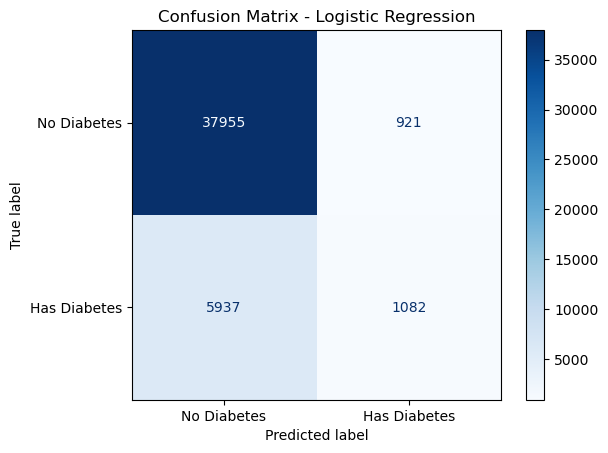

In [90]:
# Generate predictions
y_pred = logistic_model.predict(X_test)

# Create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Has Diabetes"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


  The confusion matrix shows that the model correctly identified 37,955 people without diabetes and 1,082 with diabetes. However, it misclassified 5,937 individuals with diabetes as non-diabetic, indicating a high false-negative rate. This imbalance explains the model’s low recall score (0.154), suggesting that while it is reliable at predicting non-diabetic cases, it performs poorly in identifying true diabetic individuals. Improving recall is essential for early detection and preventive healthcare applications.

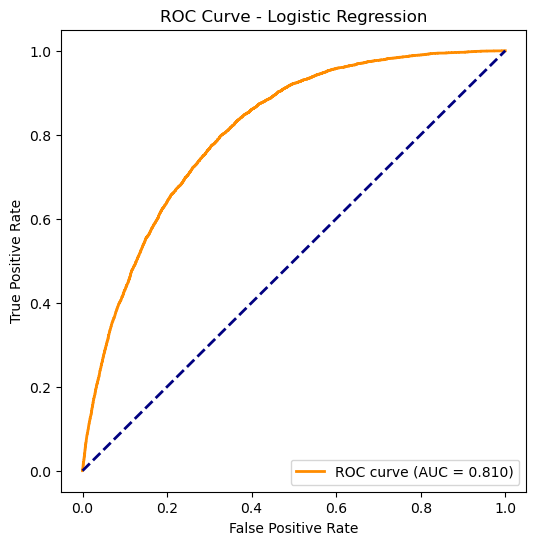

In [91]:
# Get predicted probabilities
y_pred_prob = logistic_model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_prob)
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()


This ROC curve shows how well the logistic regression model can distinguish between people with and without diabetes. The curve rises well above the diagonal dashed line, which represents random guessing, meaning the model performs better than chance. The AUC value of 0.810 indicates good discrimination ability — the model correctly ranks diabetic and non-diabetic cases. A higher AUC value closer to 1.0 would indicate excellent performance, while values near 0.5 would suggest poor predictive power.

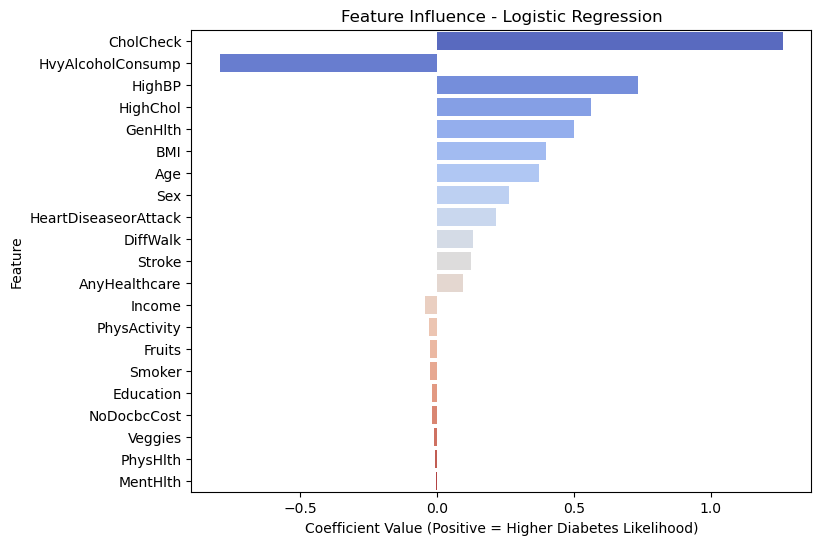

In [92]:
# Get feature importance (coefficients)
coefficients = logistic_model.coef_[0]
features = X_train.columns

# Create a DataFrame for easy visualization
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficients (By strongest influence)
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Plot the coefficients
plt.figure(figsize=(8,6))
sns.barplot(x='Coefficient', y='Feature', data=importance_df, palette='coolwarm')
plt.title("Feature Influence - Logistic Regression")
plt.xlabel("Coefficient Value (Positive = Higher Diabetes Likelihood)")
plt.ylabel("Feature")
plt.show()


 According to the logistic regression model, this chart reveals which factors have the greatest impact on diabetes risk. Cholesterol check (CholCheck), heavy drinking, high blood pressure (HighBP), and high cholesterol (HighChol) all have strong positive coefficients, showing that they raise the likelihood of diabetes. Lifestyle choices such as physical activity, healthy eating, and mental well-being help lower the diabetes risk. 

## Step 5. Random Forest

In [93]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # allow full tree depth
    random_state=42,         # ensures reproducibility
    n_jobs=-1                # uses all CPU cores for faster training
)

In [94]:
#Train the Random Forest model.
# Fit the model on the training data.
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [95]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate model performance
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print(f"Random Forest Recall: {rf_recall:.3f}")
print(f"Random Forest AUC: {rf_auc:.3f}")


Random Forest Accuracy: 0.843
Random Forest Recall: 0.168
Random Forest AUC: 0.779


 With an accuracy of 0.843, the Random Forest model correctly predicted diabetes status for about 84% of the participants. This means it correctly predicted diabetes status in most cases, both diabetic and non-diabetic. This is slightly lower than logistic regression’s 85.1%, but still strong overall. The model identified 16.8% of the people who actually have diabetes, a small improvement from logistic regression’s 15.4%, but still relatively low. The Random Forest model produced an AUC of 0.779, outperforming the logistic regression model’s AUC of 0.565 and demonstrating greater skill in identifying actual diabetes outcomes.

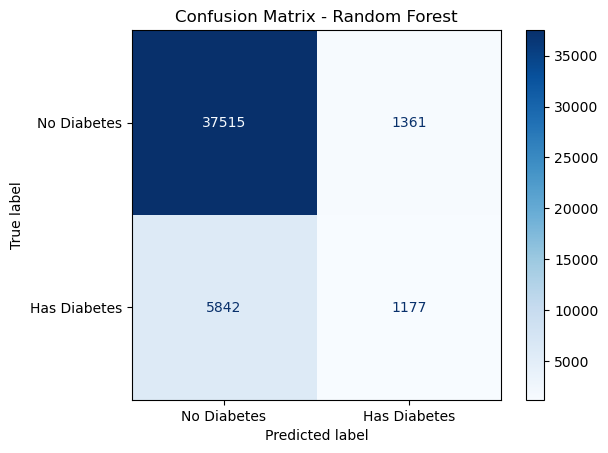

In [96]:
# Plot confusion matrix
rf_cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=["No Diabetes", "Has Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()


 The confusion matrix shows that the Random Forest model accurately identified 37,515 individuals without diabetes and 1,177 with diabetes. However, 5,842 diabetic individuals were incorrectly classified as non-diabetic. This pattern indicates slightly better recall than logistic regression, although false negatives remain high, suggesting that further tuning is needed for early detection purposes.

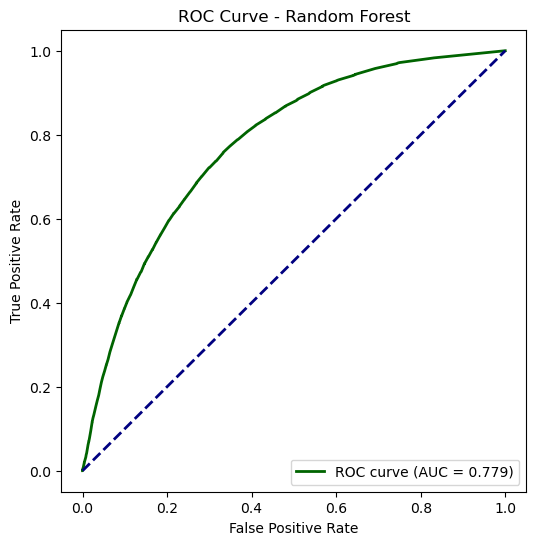

In [97]:
# Get predicted probabilities
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr_rf, tpr_rf, thresholds_rf = metrics.roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = metrics.auc(fpr_rf, tpr_rf)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr_rf, tpr_rf, color='darkgreen', lw=2, label=f"ROC curve (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()

 


 The ROC curve shows that the model can tell apart people who have diabetes from those who don’t. The curve rises above the diagonal dashed line, which means the model performs better than random guessing. The AUC score of 0.779 means the model does a fairly good job at distinguishing between the two groups, although it is slightly weaker than the logistic regression model, which scored 0.810.

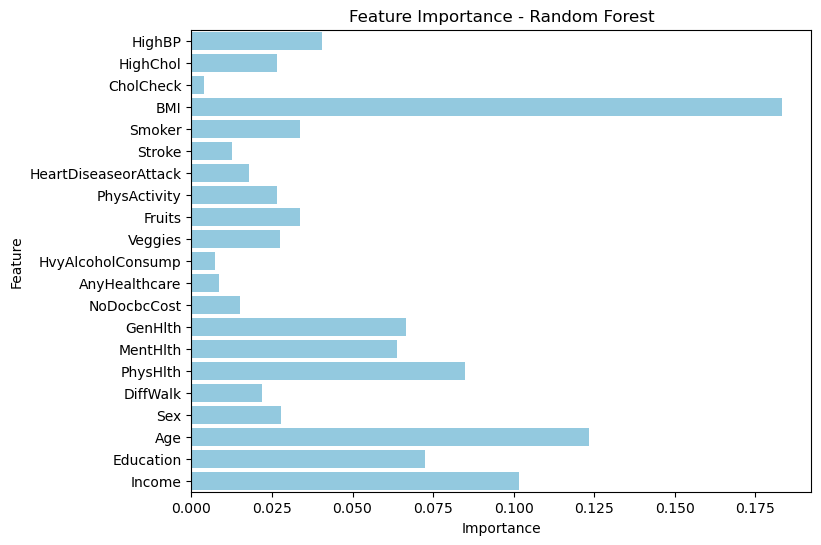

In [98]:
# Feature importance
importances = rf_model.feature_importances_
features = X_train.columns

# Plot
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=features, color='skyblue')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

This feature importance chart is identifying which factors had the strongest impact on the Random Forest model’s predictions for diabetes. BMI, age, and, surprisingly, income, were the highest predictors. This means that higher body weight, older age, and financial challenges increase the chance to being at risk for diabetes.  Physical health and general health also strongly influence predictions, showing that overall wellness affects a person’s likelihood of developing diabetes.

## Hypothesis:
Results from both models support the hypothesis that elevated BMI, higher blood pressure, and advanced age increase the risk of diabetes. These factors consistently appeared as key predictors, validating their influence on diabetes development.

## Research Question:

The research question is supported by the findings. Predictive analytics effectively identified patterns associated with diabetes risk using health indicators such as BMI, age, and blood pressure. These results demonstrate that such models can help guide early screening and preventive care efforts.

## Recommendations for Future Analysis:

Based on the project's results, two primary actions are recommended. 

•	First, healthcare organizations should integrate the random forest predictive model (AUC = 0.779) into routine patient assessments to identify individuals at higher risk of diabetes. This supports the research goal by enabling early detection and prioritizing preventive care interventions.

•	Second, invest in proactive-oriented education and health behavior change programs. High-risk groups would receive tools, knowledge, and support to modify behaviors such as their diet and physical activity, which would lower their likelihood of developing chronic conditions such as diabetes.
